# Numerical Integration

## Introduction



When we evaluate definite integrals, we naturally prefer analytical solutions: finding an antiderivative and evaluating it at the boundaries. However, many integrals that arise in engineering practice cannot be evaluated analytically, requiring numerical approximation instead. In this chapter, we examine several numerical integration schemes that balance accuracy against computational cost, allowing us to approximate integrals with controlled error.

We begin by exploring a straightforward approach: constructing integration rules that are easy to evaluate. This investigation reveals both the power and limitations of simple schemes, motivating more sophisticated methods.

Consider the definite integral of a function $f(x)$ over an arbitrary interval:

$$
\int_a^b f(x) d x
$$

To develop numerical integration rules that apply to any interval $[a,b]$, we face a fundamental challenge: designing rules that work independently of the specific limits. Rather than creating separate integration formulas for each possible interval, we use coordinate transformation to transform any interval $[a,b]$ to a standard reference interval. This approach separates the geometry of the integration domain from the integration rule itself, enabling us to develop general-purpose methods once and reuse them for arbitrary intervals.

We map any range $x \in[a, b]$ to the standard range $\xi \in[0,1]$ using the linear transformation $x(\xi):=(1-\xi) a+\xi b$. The derivative of this mapping gives $\frac{d x}{d \xi}=b-a$, which appears as the Jacobian in the change of variables:

$$
\boxed{\int_a^b f(x) d x=\int_0^1 f(x(\xi)) \frac{d x}{d \xi} d \xi=(b-a) \int_0^1 f(x(\xi)) d \xi}
$$

This transformation reveals that integration over $[a,b]$ can be computed by scaling the result from the standard interval $[0,1]$ by the interval length $b-a$.

Example: 

Let's say we want to integrate some polynomial of order $n$

$$
\int_a^b x^n d x=(b-a) \int_0^1 x(\xi)^n d \xi=(b-a) \int_0^1((1-\xi) a+\xi b)^n d \xi=-\frac{a^{n+1}-b^{n+1}}{n+1}
$$

This gives a rule for integrating polynomials of order $n$ over any range $[a,b]$, which can be implemented in code as a lookup table. For example,


$$
\int_2^5 2 x-4 x^2 d x=-2 \frac{a^{1+1}-b^{1+1}}{1+1}--4 \frac{a^{2+1}-b^{2+1}}{2+1}=-135
$$


But in general it is awkward to use this rule to integrate e.g.,
$\int_{x_1}^{x_2}(1-x)(1-x) d x$ or $\int_{x_1}^{x_2} \varphi^T \varphi d x$ without additional preparation which makes it cumbersome to implement in a computer program and run efficiently.

The same goes for the integration rulse such as

$$
\int_{-1}^1 x^n d x= \begin{cases}\frac{2}{n+1} & \text { if } n \text { is even } \\ 0 & \text { if } n \text { is odd }\end{cases}
$$

and

$$
\int_0^1 x^n d x=\frac{1}{n+1}
$$

We want a more general approach to numerical integration

## sympy.integrate

The `sympy` library in Python provides a powerful tool for symbolic mathematics, including integration. The `integrate` function can be used to compute definite and indefinite integrals of functions. This is great for analytical solutions!

Let's consider a polynomial function $f(x)=1+3 x^2-x^3$ for $x \in[0,3]$

In [2]:
# | code-fold: true
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from mechanicskit import fplot

plt.style.use('seaborn-v0_8-whitegrid') 
plt.rcParams['figure.dpi'] = 120

In [3]:
# | code-fold: false
x = sp.Symbol('x')
f_expr = 1 + 3*x**2 - x**3

x1 = 0
x2 = 3

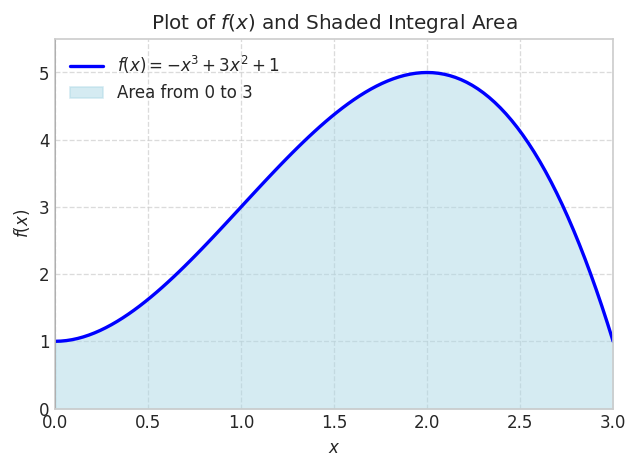

In [4]:
#| fig-dpi: 150
fig, ax = plt.subplots(figsize=(6, 4))
fplot(f_expr, range=(x1, x2), color='blue', linewidth=2, 
      label=f'$f(x) = {sp.latex(f_expr)}$')

f_numeric = sp.lambdify(x, f_expr, 'numpy')
x_fill = np.linspace(x1, x2, 500)
y_fill = f_numeric(x_fill)
ax.fill_between(x_fill, y_fill, color='lightblue', alpha=0.5, label=f'Area from {x1} to {x2}')


ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Plot of $f(x)$ and Shaded Integral Area')
ax.axhline(0, color='black', linewidth=0.5) # Add x-axis
ax.axvline(0, color='black', linewidth=0.5) # Add y-axis
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='upper left')
ax.set_xlim(x1, x2)
ax.set_ylim(0, max(y_fill)*1.1)
plt.show()

We can integrate this analytically

In [5]:
# | code-fold: False
integral_value = sp.integrate(f_expr, (x, x1, x2))
integral_value

39/4

In [6]:
# | code-fold: False
integral_value.evalf()

9.75000000000000

## Non-trivial integrals

This works very well even for functions that do not have simple symbolic integrals. 

In [7]:
# | code-fold: False
f_expr = 1/sp.sqrt(sp.sin(x))
x1 = 0
x2 = 1


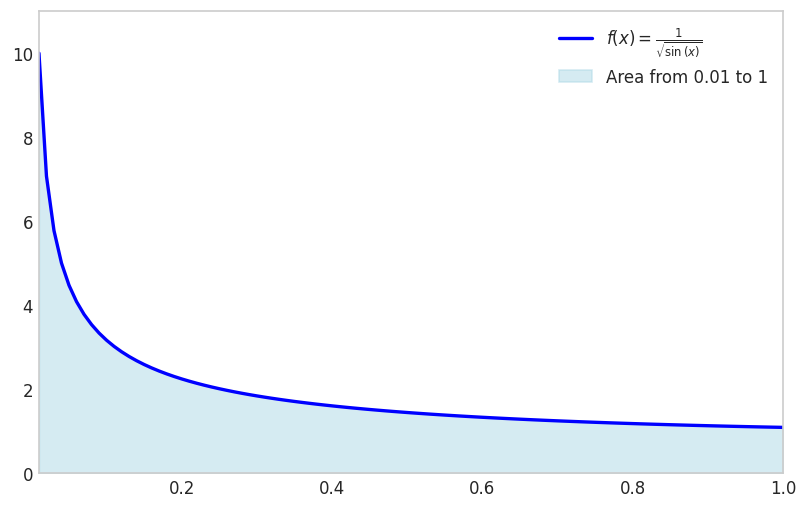

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

x1 = 0.01
fplot(f_expr, range=(x1, x2), color='blue', linewidth=2, 
      label=f'$f(x) = {sp.latex(f_expr)}$')

f_numeric = sp.lambdify(x, f_expr, 'numpy')
x_fill = np.linspace(x1, x2, 500)
y_fill = f_numeric(x_fill)
ax.fill_between(x_fill, y_fill, color='lightblue', alpha=0.5, label=f'Area from {x1} to {x2}')


ax.set_xlim(x1, x2)
ax.set_ylim(0, max(y_fill)*1.1)
ax.legend(loc='upper right')
ax.grid(False)
plt.show()

Note that we avoid the singularity by shifting the lower limit away from zero.

In [9]:
# | code-fold: False
sp.integrate(f_expr, (x, x1, x2))

Integral(1/sqrt(sin(x)), (x, 0.01, 1))

In [10]:
# | code-fold: False
x1 = 0
sp.integrate(f_expr, (x, x1, x2)).evalf()

2.03480531920757

Another example is the function $f(x)=e^{\cos(x)}$ for $x \in[0,3]$

In [11]:
# | code-fold: False
f_expr = sp.exp(sp.cos(x))
x1 = 0; x2 = 3

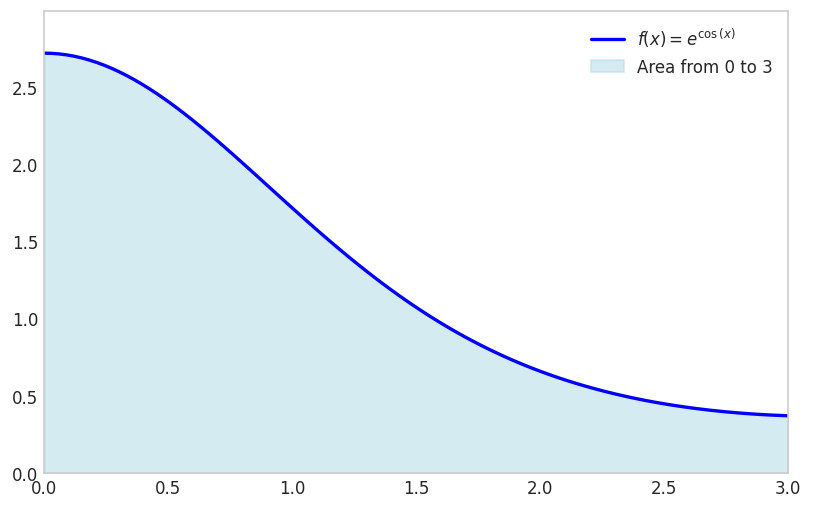

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

fplot(f_expr, range=(x1, x2), color='blue', linewidth=2, 
      label=f'$f(x) = {sp.latex(f_expr)}$')

f_numeric = sp.lambdify(x, f_expr, 'numpy')
x_fill = np.linspace(x1, x2, 500)
y_fill = f_numeric(x_fill)
ax.fill_between(x_fill, y_fill, color='lightblue', alpha=0.5, label=f'Area from {x1} to {x2}')


ax.set_xlim(x1, x2)
ax.set_ylim(0, max(y_fill)*1.1)
ax.legend(loc='upper right')
ax.grid(False)
plt.show()

In [13]:
# | code-fold: False
sp.integrate(f_expr, (x, x1, x2))

Integral(exp(cos(x)), (x, 0, 3))

Notice how `integrate` has failed to find a symbolic integral. It took a long time, and actually fell back on `sympy.Integral`.

### sympy.Integral


`sympy.integrate` can fail when the integral is too complex. In such cases, we can use the `sympy.Integral` class to represent the integral symbolically without evaluating it immediately. This allows us to manipulate the integral expression further or evaluate it later when more information is available.

In [58]:
# | code-fold: False
sp.Integral(f_expr, (x, 0, 3))

Integral(2*x*sin(12*x) + 3, (x, 0, 3))

We see here that it simply returns an unevaluated integral object.

We can however evaluate it numerically using the `evalf` method.

In [59]:
# | code-fold: False
sp.Integral(f_expr, (x, 0, 3)).evalf()

9.05020713851588


There are two options here: use `sp.integrate(f, (x, x1, x2)).evalf()` or use `sympy.Integral(f, (x, x1, x2)).evalf()`.

In [60]:
# | code-fold: False
sp.integrate(f_expr, (x, 0, 3)).evalf()

9.05020713851588

In [65]:
# | code-fold: False
sp.Integral(f_expr, (x, 0,3 )).evalf()

9.05020713851588

### sympy.integrate vs sympy.Integral

The outcome is the same, but the second option is often faster since it does not try to find a symbolic expression for the integral. If `sp.integrate` fails it will fall back to `sp.Integral`. Relying on this fallback is not good practice.

For reliably computing the numerical value of an integral, always use `sympy.Integral(...).evalf()`. It is the direct, explicit, and robust method.

Use `sympy.integrate()` only when you need the symbolic antiderivative itself.

For engineering applications requiring only occasional numerical integration, symbolic methods like `sympy.integrate` or adaptive quadrature suffice. However, finite element analysis and similar computational methods require evaluating millions of integrals: element stiffness matrices, force vectors, and residuals at every iteration of every time step. In these contexts, computational efficiency becomes paramount. We therefore examine numerical integration schemes designed for efficient implementation and repeated evaluation, focusing on methods that balance accuracy against cost in a predictable, controllable manner.

## Riemann sum

We begin our examination of numerical integration with the most fundamental approach: the [Riemann sum](https://en.wikipedia.org/wiki/Riemann_sum). This method approximates the integral by dividing the interval $[a,b]$ into $N$ subintervals of equal width $\Delta x = (b-a)/N$ and evaluating the function at one point within each subinterval. Using the left endpoint of each subinterval gives

$$
\int_a^b f(x) \approx \frac{b-a}{N} \sum_{i=1}^N f\left(x_i\right)
$$

where $x_i$ denotes the evaluation point in the $i$-th subinterval. This formula treats the integral as the limit of a sum of rectangular areas, each with width $\Delta x$ and height $f(x_i)$. While conceptually simple, we shall see that this approach converges slowly, motivating more sophisticated methods.

In [67]:
# | code-fold: true
x = sp.Symbol('x')
f_expr = 1 + 3*x**2 - x**3

x1 = 0; x2 = 3

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50  # Increase if needed
from matplotlib.colors import to_rgba

# Define N values
N_values = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50, 100, 150, 200]
N_values = list(range(2, 20, 1)) + list(range(20, 201, 5))

def animate(frame_idx):
    """Animation function for each frame"""
    ax.clear()
    
    N = N_values[frame_idx]
    
    # Compute Riemann sum data
    f_numeric = sp.lambdify(x, f_expr, 'numpy')
    dx = (x2 - x1) / N
    x_points = np.linspace(x1 + dx/2, x2 - dx/2, N)  # Center points for bars
    y_points = f_numeric(x_points - dx/2)  # Left Riemann sum (use left edge)
    
    riemann_sum = dx * np.sum(y_points)
    
    # Compute exact integral
    exact_integral = sp.Integral(f_expr, (x, x1, x2)).evalf()
    error = abs(float(exact_integral) - riemann_sum)
    
    # Determine edge opacity based on N
    if N <= 10:
        edge_alpha = 0.5
        edge_color = to_rgba('black', alpha=edge_alpha)
        linewidth = 1
    elif N < 75:
        edge_alpha = 0.5 - ((N - 10) / (75 - 10))*0.5
        edge_color = to_rgba('black', alpha=edge_alpha)
        linewidth = 1
    else:
        edge_color = 'lightcoral'
        # edge_color = to_rgba('black', alpha=0)
        linewidth = 1
    # Plot Riemann sum as bars
    ax.bar(x_points, y_points, width=dx, align='center',
           facecolor='lightcoral', 
        #    alpha=1,
           edgecolor=edge_color, linewidth=linewidth,
           label='Riemann Sum')
    
    # Plot the function on top
    x_plot = np.linspace(x1, x2, 500)
    y_plot = f_numeric(x_plot)
    ax.plot(x_plot, y_plot, color='blue', linewidth=2, 
            label=f'$f(x) = {sp.latex(f_expr)}$', zorder=5)
    
    # Set labels and limits
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$f(x)$', fontsize=12)
    ax.set_xlim(x1, x2)
    y_max = max(f_numeric(np.linspace(x1, x2, 500)))
    ax.set_ylim(0, y_max * 1.2)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    
    # Add text box with results
    textstr = f'$N = {N}$\n'
    textstr += f'Exact Integral: ${exact_integral:.6f}$\n'
    textstr += f'Riemann Sum: ${riemann_sum:.6f}$\n'
    textstr += f'Error: ${error:.6f}$'
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
    
    ax.legend(loc='upper right')

# Create figure and axis (close to prevent static display)
fig, ax = plt.subplots(figsize=(6, 4))
plt.close(fig)  # Prevent static image from showing

# Create animation
anim = FuncAnimation(fig, animate, frames=len(N_values), 
                     interval=800, repeat=True)

# Display as interactive HTML
# HTML(anim.to_jshtml())

# Get the HTML and wrap it with responsive CSS
anim_html = anim.to_jshtml()

# Convert to responsive HTML
import mechanicskit as mk
mk.to_responsive_html(anim, container_id='riemann_sum_animation')

To assess the Riemann sum's accuracy quantitatively, we measure the absolute integration error as the difference between the Riemann approximation and the exact integral value:

$$
\epsilon=\left|I_{\text {Riemann }}-I_{\text {exact }}\right|
$$

For our polynomial example with $N=200$ function evaluations, we obtain:

In [68]:
# | code-fold: false
N = 200
f_numeric = sp.lambdify(x, f_expr, 'numpy')
dx = (x2 - x1) / N

x_points = np.linspace(x1, x2, N) 
y_points = f_numeric(x_points)  
    
I_riemann = dx * np.sum(y_points)
I_exact = sp.Integral(f_expr, (x, x1, x2)).evalf()

In [69]:
# | code-fold: false
error_riemann = abs( I_exact - I_riemann)
error_riemann

0.0339195979899500

Note that the absolute integration error is still significantly large after 200 function evaluations!

This slow convergence reveals the central challenge in numerical integration: developing schemes that reduce error more rapidly as we increase the number of function evaluations. Since computational cost scales directly with the number of evaluations $N$, methods that achieve a given accuracy with fewer evaluations provide substantial practical advantage. The trapezoidal rule, which we examine next, demonstrates how a simple refinement can dramatically improve convergence.

## Trapezoidal rule {#sec-trapezoidal-rule}

The Riemann sum approximates the function as piecewise constant over each subinterval. A natural improvement uses piecewise linear approximation instead, connecting function values at adjacent points with straight line segments. This geometric insight leads to the trapezoidal rule.

Over a single interval $[a,b]$, we approximate the function linearly using shape functions that interpolate between the endpoint values: $f(x) \approx \varphi_1(x) f(a)+\varphi_2(x) f(b)$ where $\varphi_1(x)=(b-x)/(b-a)$ and $\varphi_2(x)=(x-a)/(b-a)$. Integrating this linear approximation over the interval gives


$$
I \approx \frac{f(a)}{b-a} \int_a^b b-x d x+\frac{f(b)}{b-a} \int_a^b x-a d x=\frac{f(a)}{b-a}\left[b x-\frac{1}{2} x^2\right]_a^b+\frac{f(b)}{b-a}\left[\frac{1}{2} x^2-a x\right]_a^b
$$

$$
=\frac{f(a)}{b-a}\left(b^2-\frac{1}{2} b^2-a b-\frac{1}{2} a^2\right)+\frac{f(b)}{b-a}\left(\frac{1}{2} b^2-a b-\frac{1}{2} a^2-a^2\right) \\
$$

$$
=\frac{f(a)}{b-a} \frac{1}{2}(b-a)^2+\frac{f(b)}{b-a} \frac{1}{2}(b-a)^2 \\
$$



$$
=\frac{1}{2}(b-a)(f(a)+f(b))
$$

This is called the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule). And for a chained approximation with $N+1$ evenly spaced points the approximation becomes:

$$
\boxed{\int_a^b f(x) d x \approx \frac{b-a}{2 N} \sum_{i=1}^N\left(f\left(x_i\right)+f\left(x_{i+1}\right)\right)}
$$

For example for the function above using $N=200$ we have:

In [21]:
# | code-fold: false
f_expr = 1 + 3*x**2 - x**3
x1 = 0; x2 = 3

I_exact = sp.Integral(f_expr, (x, x1, x2)).evalf()

N = 200
f_numeric = sp.lambdify(x, f_expr, 'numpy')

x_points = np.linspace(x1, x2, N+1) 

x_i =  x_points[0:-1]
x_i1 = x_points[1:]
I_trapz = np.sum(f_numeric(x_i) + f_numeric(x_i1)) * (x2-x1)/(2*N)
I_trapz


np.float64(9.74983125)

In [22]:
# | code-fold: false
error_trapz = abs(I_exact - I_trapz)
error_trapz

0.000168750000000273

:::important
Trapezoidal rule gives much better accuracy than the Riemann sum for the same number of function evaluations!
There is a built-in function in `numpy` for the trapezoidal rule: `numpy.trapezoid`
:::

In [23]:
# | code-fold: false
np.trapezoid(f_numeric(x_points), x_points)

np.float64(9.74983125)

In [24]:
# | code-fold: false
error_riemann/error_trapz

201.005025125305

We see a 200x improvement in accuracy for the same number of function evaluations!

The dramatic improvement in accuracy reveals different error scaling laws. Riemann sum error decreases as $O(h^2)$ where $h=(b-a)/N$ is the interval width, meaning that halving the interval reduces error by a factor of 4. Trapezoidal rule error decreases as $O(h^3)$ for smooth functions, giving eightfold error reduction when halving the interval. For our problem with $N=200$ subintervals, the ratio of error scaling terms $(1/N)^2 / (1/N)^3 = N$ explains the observed 200-fold improvement. This $O(h^3)$ convergence makes the trapezoidal rule practical for many applications, though Gaussian quadrature achieves even faster convergence through optimal node placement.

In [73]:
# | code-fold: true
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50  # Increase if needed
from matplotlib.colors import to_rgba

f_expr = 1 + 3*x**2 - x**3
x1 = 0; x2 = 3
f_numeric = sp.lambdify(x, f_expr, 'numpy')

I_exact = sp.Integral(f_expr, (x, x1, x2)).evalf()

N_values = list(range(4, 20, 1)) + list(range(20, 201, 5))
# N_values = [4,8,15]

def makePlot(N):
   x_points = np.linspace(x1, x2, N+1) 
   
   dx = (x2 - x1) / (N+1)
   y_points = f_numeric(x_points)  
   I_riemann = dx * np.sum(y_points)
   error_riemann = abs( I_exact - I_riemann)
   
   x_i =  x_points[0:-1]
   x_i1 = x_points[1:]
   
   I_trapz = np.sum(f_numeric(x_i) + f_numeric(x_i1)) * (x2-x1)/(2*N)
   error_trapz = abs(I_exact - I_trapz)

   if N <= 10:
      edge_alpha = 0.5
      edge_color = to_rgba('black', alpha=edge_alpha)
   elif N < 50:
      edge_alpha = 0.5 - ((N - 10) / (50 - 10))*0.5
      edge_color = to_rgba('black', alpha=edge_alpha)
   else:
      edge_color = to_rgba('cyan', alpha=0)

#    fig, ax = plt.subplots(figsize=(6, 4))
   ax.grid(False)
   for iel in range(N):
      xs = [x_i[iel], x_i[iel], x_i1[iel], x_i1[iel]]
      ys = [0, f_numeric(x_i[iel]), f_numeric(x_i1[iel]), 0]
      ax.fill(xs, ys, facecolor = to_rgba('cyan', alpha=0.7), 
               edgecolor = edge_color)

   # Plot the function on top
   x_plot = np.linspace(x1, x2, 500)
   y_plot = f_numeric(x_plot)
   ax.plot(x_plot, y_plot, color='blue', linewidth=2, 
         label=f'$f(x) = {sp.latex(f_expr)}$', zorder=5)
   
   # Set labels and limits
   ax.set_xlabel('$x$', fontsize=12)
   ax.set_ylabel('$f(x)$', fontsize=12)
   ax.set_xlim(x1, x2)
   y_max = max(f_numeric(np.linspace(x1, x2, 500)))
   ax.set_ylim(0, y_max * 1.2)
   ax.grid(True, linestyle='--', alpha=0.7)
   ax.axhline(0, color='black', linewidth=0.5)
   ax.axvline(0, color='black', linewidth=0.5)
   
   # Add text box with results
   textstr = f'$N = {N}$\n'
   textstr += f'I_e: ${I_exact:.6f}$\n'
   textstr += f'I_R: ${I_riemann:.6f}$, error:${error_riemann:.4f}$\n'
   textstr += f'I_T: ${I_trapz:.6f}$, error:${error_trapz:.4f}$'
   
   props = dict(boxstyle='round', facecolor='w', alpha=0.8)
   ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', bbox=props)
   
   ax.legend(loc='upper right')

def animate(frame_idx):
    """Animation function for each frame"""
    ax.clear()
    
    N = N_values[frame_idx]
    makePlot(N)

# Create figure and axis (close to prevent static display)
fig, ax = plt.subplots(figsize=(6, 4))
plt.close(fig)  # Prevent static image from showing

# Create animation
anim = FuncAnimation(fig, animate, frames=len(N_values), 
                     interval=800, repeat=True)

mk.to_responsive_html(anim, container_id='trapz_animation')

## Exact numerical integration of polynomials


The trapezoidal rule integrates linear polynomials exactly:

$$
\int_a^b p_1(x) d x = \frac{b-a}{2}(p_1(a)+p_1(b))
$$

where $p_1(x)=c_0+c_1 x$ is a polynomial of order 1.

In [26]:
# | code-fold: false
x = sp.Symbol('x')
f_expr = 1 + 3*x
x1 = 0; x2 = 3
f_numeric = sp.lambdify(x, f_expr, 'numpy')

x_points = np.linspace(x1, x2, 2)
np.trapezoid(f_numeric(x_points), x_points)

np.float64(16.5)

In [27]:
# | code-fold: false
sp.Integral(f_expr, (x, x1, x2)).evalf()

16.5000000000000

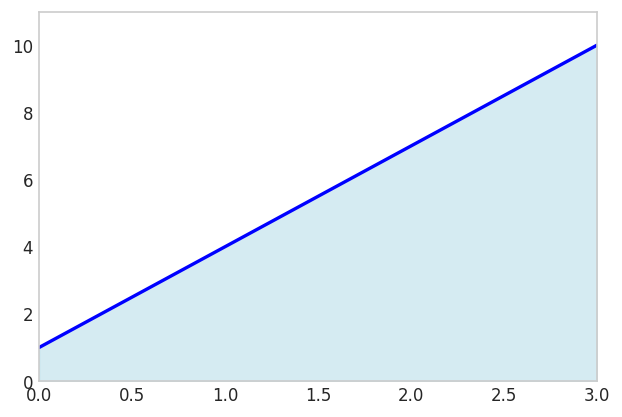

In [28]:
# | code-fold: true

fig, ax = plt.subplots(figsize=(6, 4))

fplot(f_expr, range=(x1, x2), color='blue', linewidth=2, 
      label=f'$f(x) = {sp.latex(f_expr)}$')

x_fill = np.linspace(x1, x2, 2)
y_fill = f_numeric(x_fill)
ax.fill_between(x_fill, y_fill, color='lightblue', alpha=0.5, label=f'Area from {x1} to {x2}')
ax.grid(False)
ax.set_xlim(x1, x2)
ax.set_ylim(0, max(y_fill)*1.1)
fig.show()

Since two points define a line, the trapezoidal rule will always give the exact result for linear polynomials.

A cheaper option is to evaluate the midpoint $\frac{a+b}{2}$ instead:

In [29]:
# | code-fold: false
xm = (x1 + x2)/2

(x2-x1)*f_numeric(xm)

16.5

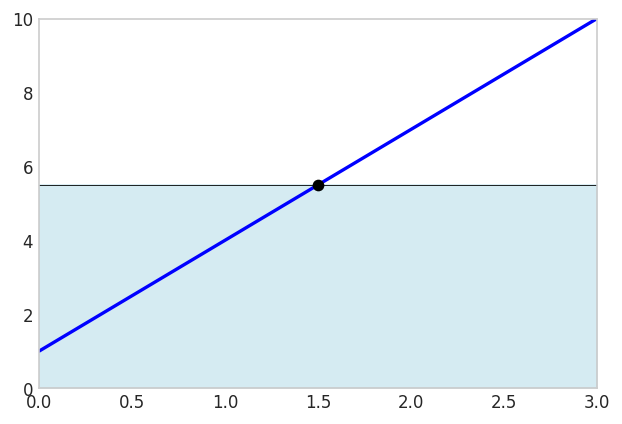

In [30]:
# | code-fold: true

fig, ax = plt.subplots(figsize=(6, 4))

fplot(f_expr, range=(x1, x2), color='blue', linewidth=2, 
      label=f'$f(x) = {sp.latex(f_expr)}$')

x_fill = np.linspace(x1, x2, 2)
y_m = f_numeric(xm)

ax.fill_between(x_fill, [y_m], color='lightblue', alpha=0.5, label=f'Area from {x1} to {x2}')
ax.plot([xm], [y_m], color='k', marker='o')
ax.plot([x1, x2], [y_m, y_m], color='k', linestyle='-', lw=0.5)
ax.grid(False)
ax.set_xlim(x1, x2)
ax.set_ylim(0, 10)
fig.show()

This is exact because the error above the graph cancels the error below the graph!

## Gauss quadrature rule

::: {layout-ncol=2}
![Carl Friedrich Gauss](graphics/Gauss.png){width=20em }

![Carl Friedrich Gauss on the German 10-Mark bill, accompanied by his namesake Gaussian distribution. A tribute to Germany's rich mathematical heritage.](graphics/Gauss10.png){width=20em }
:::

The Riemann sum and trapezoidal rule use equally spaced evaluation points, a seemingly natural choice but not, as it turns out, optimal. Gaussian quadrature achieves a remarkable result: by carefully selecting both the evaluation points (nodes) and their weights, an $n$-point rule can integrate polynomials of degree $2n-1$ exactly. This doubling of precision compared to methods using equally spaced points makes Gaussian quadrature the method of choice when high accuracy is required from a limited number of function evaluations.

::: {.callout-note}
An n-point Gaussian quadrature rule can integrate a polynomial of degree `2n-1` **exactly**. This is a remarkable result and is what makes the method so powerful. For a given number of function evaluations, Gaussian quadrature provides the highest possible accuracy.
:::

The general form of an n-point Gaussian quadrature for the standard domain $x\in[-1,1]$ is:

$$
\boxed{\int_{-1}^{1} f(x) dx \approx \sum_{i=1}^{n} w_i f(x_i)}
$$

where `x_i` are the nodes and `w_i` are the weights. Notice that the integral is defined on the interval `[-1, 1]`. This is the standard "reference" interval for Gaussian quadrature.

### From $[-1, 1]$ to $[a, b]$

To use Gaussian quadrature on a different interval, say from $a$ to $b$, we need to perform a change of variables. We can map a new variable $\xi$ in $[-1, 1]$ to our variable $x$ in $[a, b]$ using the following linear transformation:


$$ 
 x = \frac{b-a}{2}\xi + \frac{a+b}{2} 
$$ 

When we substitute this into the integral, we also need to change the differential $dx$. We get the map by differentiating $\frac{dx}{d\xi}$

We have

$$
\int_a^b f(x) d x=\int_{-1}^1 f(x(\xi)) \frac{d x}{d \xi} d \xi
$$

and with

$$
\dfrac{d x}{d \xi}=\frac{b-a}{2}
$$

we get

$$ 
 \int_{a}^{b} f(x) dx = \int_{-1}^{1} f\left(\frac{b-a}{2}\xi + \frac{a+b}{2}\right) \frac{b-a}{2} d\xi 
$$ 

and with Gaussian quadrature we have

::: important
$$
\int_{-1}^{1} p\left(\frac{b-a}{2}\xi + \frac{a+b}{2}\right) \frac{b-a}{2} d\xi = \frac{b-a}{2} \sum_{i=1}^{n} w_i p\left(\frac{b-a}{2}x_i + \frac{a+b}{2}\right)
$$
:::

where $p(\xi)$ is a polynomial of degree `2n-1`. 


::: {:callout-note}
We recognize that $dx = \frac{b-a}{2} d\xi$, where $d \xi$ is the size of the integration element in the standard domain, i.e., for [-1, 1] we have $d \xi = 2$. This is naturally handled by the weights `w_i` in the Gaussian quadrature formula, since they sum to 2 for the standard domain.
:::

Now, we can apply the Gaussian quadrature rule to the integral on the right-hand side.

### Nodes and Weights for Gauss-Legendre Quadrature


The optimal nodes $\xi_i$ for Gaussian quadrature are the roots of the $n$-th Legendre polynomial $P_n(\xi)$, while the weights $w_i$ can be computed analytically from these roots. For low-order rules ($n \leq 4$), these values have simple closed forms that we list here for reference. Higher-order rules require numerical computation of polynomial roots and weights, which we address later using the Golub-Welsch algorithm.

The table below presents nodes and weights for $n=1$ through $n=4$ on the standard interval $[-1, 1]$. These low-order rules suffice for many applications and provide concrete examples before we examine the general theory.

| $n$ | Nodes ($\xi_i$) | Weights ($w_i$) |
|:---:|:---|:---|
| **1** | $0$ | $2$ |
| **2** | $\pm 1/\sqrt{3} \approx \pm 0.57735$ | $1$ |
| **3** | $0$ <br> $\pm \sqrt{3/5} \approx \pm 0.77460$ | $8/9$ <br> $5/9$ |
| **4** | $\pm \sqrt{ \frac{3 - 2\sqrt{6/5}}{7} } \approx \pm 0.33998$ <br> $\pm \sqrt{ \frac{3 + 2\sqrt{6/5}}{7} } \approx \pm 0.86114$ | $\frac{18 + \sqrt{30}}{36} \approx 0.65215$ <br> $\frac{18 - \sqrt{30}}{36} \approx 0.34785$ |


### Example: $\int_0^1 x dx$

In [31]:
# | code-fold: false
x = sp.Symbol('x')
f_expr = x
x1 = 0; x2 = 1
I_e = sp.Integral(f_expr, (x, x1, x2)).evalf()
I_e

0.500000000000000

In [32]:
# | code-fold: false
gp = 0; gw = 2;

I_G = gw * f_expr.subs(x, (x2 - x1)/2 + x1) * (x2 - x1)/2
I_G

0.500000000000000

Ok, not a big deal, after all, even the Riemann sum is exact for linear polynomials.

### Example: $\int_0^1 1 + 3x^2 - 3x^3 dx$

The two-point Gauss rule can integrate polynomials up to degree $2(2)-1=3$ exactly. We demonstrate this with a cubic polynomial over $[0,1]$, showing both the coordinate transformation from $[0,1]$ to $[-1,1]$ and the exact integration with only two function evaluations.

Applying the coordinate transformation $x = \frac{1}{2}(1+\xi)$ maps $\xi \in [-1,1]$ to $x \in [0,1]$ with Jacobian $dx/d\xi = 1/2$. The Gaussian quadrature formula becomes

$$
\int_0^1 p(x) \, dx = \frac{1}{2}\int_{-1}^1 p\left(\frac{1+\xi}{2}\right) d\xi = \frac{1}{2}\sum_{i=1}^2 w_i \, p\left(\frac{1+\xi_i}{2}\right)
$$

where $\xi_1, \xi_2$ are the two-point Gauss nodes and $w_1, w_2$ the corresponding weights. For our cubic polynomial this gives

$$
\int_0^1 1+3 x-3 x^3 d x=\sum_i^2 p\left(x_i\right) \frac{1}{2}w_i\\
$$

where $x_1=\frac{b-a}{2}\xi_1 + \frac{a+b}{2}$ and $x_2=\frac{b-a}{2}\xi_2 + \frac{a+b}{2}$ and $w_{1,2}=1$

In [33]:
# | code-fold: false
x = sp.Symbol('x')
p = lambda x: 1 + 3*x**2 - 3*x**3 
sp.Integral(p(x), (x, 0, 1)).evalf()

1.25000000000000

In [34]:
# | code-fold: false
a = 0; b = 1
gp = [-1/sp.sqrt(3), 1/sp.sqrt(3)]
gw = [1, 1]

x1 = gp[0]*(b - a)/2 + (b + a)/2
x2 = gp[1]*(b - a)/2 + (b + a)/2

dx = (b - a)/2

I_Gauss = p(x1)*gw[0]*dx + \
          p(x2)*gw[1]*dx
I_Gauss

-1.5*(sqrt(3)/6 + 0.5)**3 - 1.5*(0.5 - sqrt(3)/6)**3 + 1.5*(0.5 - sqrt(3)/6)**2 + 1.5*(sqrt(3)/6 + 0.5)**2 + 1.0

In [35]:
# | code-fold: false
I_Gauss.simplify()

1.25000000000000

The importance of this result cannot be overstated. With just two function evaluations, we have achieved exact integration for a cubic polynomial, which is a significant improvement over simpler methods like the trapezoidal rule or midpoint rule that would require many more evaluations to reach the same level of accuracy.

### Visualizing Gauss Quadrature

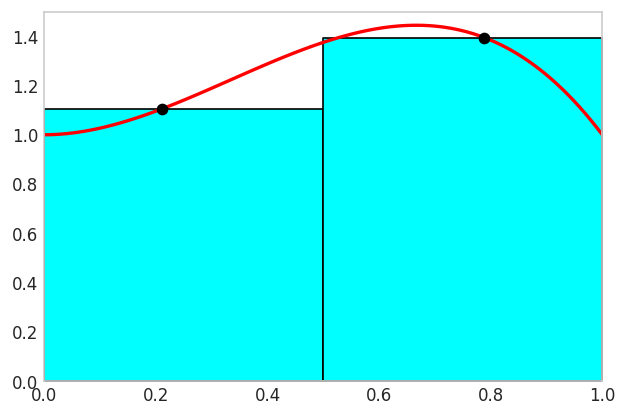

In [36]:
# | code-fold: false
x = sp.Symbol('x')
p = 1 + 3*x**2 - 3*x**3 
p_num = sp.lambdify(x, p, 'numpy')
a = 0; b = 1

gp = [-1/np.sqrt(3), 1/np.sqrt(3)]
gw = [1, 1]

x1 = gp[0]*(b - a)/2 + (b + a)/2
x2 = gp[1]*(b - a)/2 + (b + a)/2

dx = (b - a)/2

fig, ax = plt.subplots(figsize=(6, 4))

fplot(p, range=(a, b), color='red', linewidth=2, 
      label=f'$f(x) = {sp.latex(p)}$')

y1 = p_num(x1)
y2 = p_num(x2)

ax.fill_between([0,0.5], [y1, y1], color='cyan',edgecolor='k')
ax.fill_between([0.5,1], [y2, y2], color='cyan',edgecolor='k')
ax.plot([x1,x2], [y1,y2], color='k', marker='o', linestyle='None')
ax.grid(False)
ax.set_xlim(a, b)
ax.set_ylim(0, 1.5)
fig.show()

The figure visualizes the Gauss integration rule in action. The cyan and white areas between the curves are cancelling out!

::: {.callout-important}
Higher order Gauss integration will not make the integral any more accurate, the computed value will be the same. We will just be wasting computational power.
:::

## Legendre Polynomials and Their Role in Gaussian Quadrature

The optimality of Gaussian quadrature arises from a deep connection to orthogonal polynomials. Two functions $f$ and $g$ are orthogonal on an interval $[a,b]$ with respect to a weight function $w(x)$ if their inner product vanishes:

$$
\int_a^b w(x) f(x) g(x) \, dx = 0
$$

Legendre polynomials $P_n(x)$ form an orthogonal family on $[-1,1]$ with unit weight function $w(x)=1$:

$$
\int_{-1}^{1} P_m(x)P_n(x) \, dx = 0 \quad \text{for } m \neq n
$$

This orthogonality property is the key to understanding why Gaussian quadrature is optimal. The optimality arises from solving a fundamental optimization problem: given $n$ evaluation points, where should we place them to integrate the highest possible polynomial degree exactly? The answer lies in orthogonal polynomials.

When we approximate a function using an orthogonal polynomial basis, each basis function captures a distinct component of the function with no redundancy. This orthogonality ensures that the polynomial interpolant minimizes the approximation error in the least-squares sense. The roots of $P_n(x)$ are the points where the $n$-th degree polynomial oscillates through zero, and remarkably, these are precisely the optimal locations for function evaluation in an $n$-point quadrature rule. By using these nodes, we achieve exact integration for polynomials of degree $2n-1$ rather than merely degree $n-1$, effectively doubling the precision for the same computational cost.

The first few [Legendre polynomials](https://en.wikipedia.org/wiki/Legendre_polynomials) are:

*   $P_0(x) = 1$
*   $P_1(x) = x$
*   $P_2(x) = \frac{1}{2}(3x^2 - 1)$
*   $P_3(x) = \frac{1}{2}(5x^3 - 3x)$
*   $P_4(x) = \frac{1}{8}(35x^4 - 30x^2 + 3)$

The fundamental theorem of Gaussian quadrature states that the roots of $P_n(x)$ are the optimal nodes for an $n$-point rule, enabling exact integration of polynomials up to degree $2n-1$. This remarkable result (that $n$ carefully chosen points can exactly integrate polynomials of degree $2n-1$ rather than merely degree $n-1$) represents a doubling of precision compared to equally spaced methods.

See [Gauss-Legendre Quadrature on Wikipedia](https://en.wikipedia.org/wiki/Gauss%E2%80%93Legendre_quadrature) for more information.

## Historical Context for Gaussian Quadrature

The remarkable properties of Gaussian quadrature (exact integration of degree $2n-1$ polynomials with only $n$ points) were discovered by Carl Friedrich Gauss in 1814, though the method gained widespread practical use only with the development of efficient algorithms for computing nodes and weights.

Gauss published his seminal work *Methodus nova integralium valores per approximationem inveniendi* (A New Method for Finding the Values of Integrals by Approximation), introducing the revolutionary concept of choosing both evaluation points and weights optimally to maximize accuracy. His method effectively doubled the precision of numerical integration compared to existing Newton-Cotes formulas, achieving exact integration of degree $2n-1$ polynomials with $n$ points. Gauss calculated nodes and weights by hand with 16-digit precision for orders up to $n=7$, a remarkable computational feat.

The theoretical foundation was extended by Carl Gustav Jacob Jacobi in 1826, who connected Gaussian quadrature to orthogonal polynomials, particularly Legendre polynomials whose roots define the nodes. This connection provided an elegant mathematical framework for understanding and generalizing the method.

Despite its theoretical elegance, practical application remained limited by the computational difficulty of determining nodes and weights for higher orders. The advent of modern computers and the development of the Golub-Welsch algorithm in 1969 transformed Gaussian quadrature into a widely practical tool, which we examine next.

## The Golub-Welsch Algorithm

For higher-order Gaussian quadrature, finding the nodes and weights becomes more complex. The Golub-Welsch algorithm provides a stable and efficient method for computing them. See @golubwelsch1969 for the original paper.

The algorithm connects the problem of finding the nodes and weights to the eigenvalue problem of a symmetric tridiagonal matrix. The nodes of an n-point Gaussian quadrature are the eigenvalues of a specific `n x n` tridiagonal matrix called the Jacobi matrix. The weights can be calculated from the first components of the normalized eigenvectors.

Fortunately, we don't need to implement this algorithm ourselves. SciPy provides functions to calculate the nodes and weights for various types of Gaussian quadrature. For Gauss-Legendre quadrature (the most common type), we can use `scipy.special.roots_legendre`.

Here is an example of how to use it in Python:

In [37]:
# | code-fold: false
import numpy as np
from scipy.special import roots_legendre

# Get nodes and weights for n=5 in [-1, 1]
n = 2
nodes, weights = roots_legendre(n)

In [38]:
# | code-fold: false
nodes

array([-0.57735027,  0.57735027])

In [39]:
# | code-fold: false
weights

array([1., 1.])

We can define a function to perform Gaussian quadrature using SciPy:

In [71]:
# | code-fold: false
import numpy as np
import scipy
def gauss(f, a, b, n):
    """
    Compute integral of f over [a,b] using n-point Gauss-Legendre quadrature.

    Maps the standard Gauss nodes from [-1,1] to [a,b], evaluates f at
    the transformed nodes, and scales by the interval length Jacobian.
    """
    # Get n nodes and weights for standard interval [-1, 1]
    nodes, weights = scipy.special.roots_legendre(n)
    integral = 0
    for i in range(n):
        # Transform node from [-1,1] to [a,b] using x = (b-a)/2 * xi + (a+b)/2
        xi = 0.5 * (b - a) * nodes[i] + 0.5 * (b + a)
        
        # Accumulate weighted function values
        integral += weights[i] * f(xi)
        
    # Scale by Jacobian dx/dxi = (b-a)/2
    integral *= 0.5 * (b - a)
    return integral

In [41]:
# | code-fold: false
x = sp.Symbol('x')
p = lambda x: 1 + 3*x**2 - 3*x**3 
sp.Integral(p(x), (x, 0, 1)).evalf()

1.25000000000000

In [42]:
def f(x):
    return 1 + 3*x**2 - 3*x**3
gauss(f, 0, 1, 2)

np.float64(1.2500000000000002)

## mechanicskit.gaussint()

Of course we include this in the `mechanicskit` library for easy use. The function parameter can be symbolic, lambda or a normal python function as shown above.

In [43]:
# | code-fold: false
from mechanicskit import gaussint
import sympy as sp

Symbolic functions work

In [44]:
# | code-fold: false
x = sp.Symbol('x')
gaussint(1 + 3*x**2 - 3*x**3, 0, 1, n=2)

np.float64(1.25)

We can use lambda functions

In [45]:
# | code-fold: false
gaussint(lambda x: 1 + 3*x**2 - 3*x**3, 0, 1, n=2)

np.float64(1.2500000000000002)

And we can use normal python functions

In [46]:
# | code-fold: false
def f(x):
    return 1 + 3*x**2 - 3*x**3
gaussint(f, 0, 1, n=2)

np.float64(1.2500000000000002)

## Non-trivial integrals with Gauss quadrature

Note that Gauss quadrature does not exactly integrate nonpolynomial functions in general.

Let's say we need to integrate the function

$$
f(x)=\frac{1}{\sqrt{\sin (x)}} \text { for } x \in[0,1]
$$


The resulting integral

$$
\int_0^1 \frac{1}{\sqrt{\sin (x)}} d x
$$

is non-elementary.

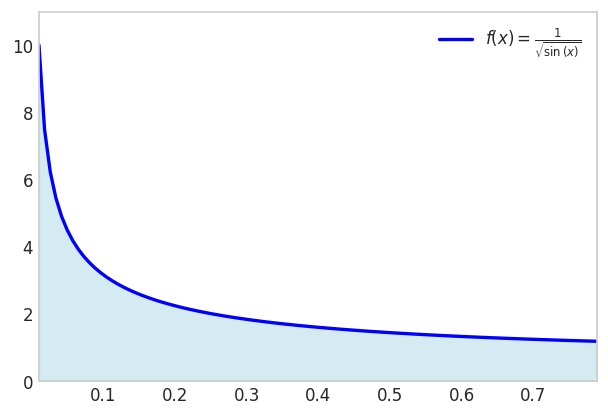

In [47]:
# | code-fold: true
x = sp.Symbol('x')
f_expr = 1/sp.sqrt(sp.sin(x))

a = 0; b = 1

fig, ax = plt.subplots(figsize=(6, 4))

x1 = 0.01
fplot(f_expr, range=(x1, x2), color='blue', linewidth=2, 
      label=f'$f(x) = {sp.latex(f_expr)}$')

f_numeric = sp.lambdify(x, f_expr, 'numpy')
x_fill = np.linspace(x1, x2, 500)
y_fill = f_numeric(x_fill)
ax.fill_between(x_fill, y_fill, color='lightblue', alpha=0.5)


ax.set_xlim(x1, x2)
ax.set_ylim(0, max(y_fill)*1.1)
ax.legend(loc='upper right')
ax.grid(False)
plt.show()

In [48]:
# | echo: false
import time

In [49]:
# | code-fold: false
start_time = time.perf_counter()

result = sp.Integral(f_expr, (x, 0, 1)).evalf()

end_time = time.perf_counter()
duration = end_time - start_time

print(f"Result: {result}")
print(f"Evaluation took {duration:.6f} seconds")

Result: 2.03480531920757
Evaluation took 0.128875 seconds


## scipy.integrate.quad

While our `gaussint` function uses a fixed number of evaluation points, production-quality integration often requires adaptive methods that automatically adjust the sampling density based on the integrand's behavior. The `scipy.integrate.quad` function provides this capability through the QUADPACK library's `QAGS` routine.

The method employs [Gauss-Kronrod quadrature rules](https://en.wikipedia.org/wiki/Gauss%E2%80%93Kronrod_quadrature_formula), which extend Gaussian quadrature by adding $n+1$ points to an $n$-point Gaussian rule. This nested structure allows simultaneous computation of two approximations: one from the $n$-point Gauss rule and one from the $(2n+1)$-point Kronrod rule. Comparing these approximations provides a robust error estimate without requiring additional function evaluations. When the estimated error exceeds tolerance, the algorithm subdivides the interval and applies the same process recursively, concentrating evaluation points where the integrand varies most rapidly.

We apply this method to our test integral to compare with the symbolic and fixed-point Gaussian results:

In [50]:
# | code-fold: false
from scipy.integrate import quad
f_num = sp.lambdify(x, f_expr, 'numpy')

start_time = time.perf_counter()

I_Quad, error = quad(f_num, 0, 1)

end_time = time.perf_counter()
duration = end_time - start_time

print(f"Result: {I_Quad}")
print(f"Estimated error: {error}")
print(f"Evaluation took {duration:.6f} seconds")

Result: 2.0348053192075737
Estimated error: 9.121112753973648e-10
Evaluation took 0.000413 seconds


In [51]:
# | code-fold: false
start_time = time.perf_counter()

I_G = gaussint(f_expr, 0, 1, n=1000)

end_time = time.perf_counter()
duration = end_time - start_time

error = abs(I_Quad - I_G)


print(f"Result: {I_G}")
print(f"Error vs quad: {error}")
print(f"Evaluation took {duration:.6f} seconds")

Result: 2.0339350641331047
Error vs quad: 0.0008702550744690285
Evaluation took 0.031276 seconds


The choice between fixed-point Gaussian quadrature and adaptive methods depends on the application context. For exploratory integration of arbitrary functions (particularly those with unknown smoothness or potential singularities), adaptive methods like `scipy.integrate.quad` provide robustness and automatic error control. However, fixed-point Gaussian quadrature remains the method of choice in finite element analysis and other applications requiring repeated integration of smooth functions over standard domains, where the overhead of adaptive subdivision cannot be justified. Our `mechanicskit.gaussint()` function serves pedagogical purposes, illustrating the core principles that underlie both approaches. When learning numerical integration, implementing and experimenting with basic Gaussian quadrature builds understanding of the fundamental ideas (orthogonal polynomials, optimal node placement, and weight computation) that inform more sophisticated adaptive schemes.

## Example: A sinusoidal function


$$
u(x)=2 x \sin (2 \pi x)+3 \text { for } x \in[-0.3,0.9]
$$

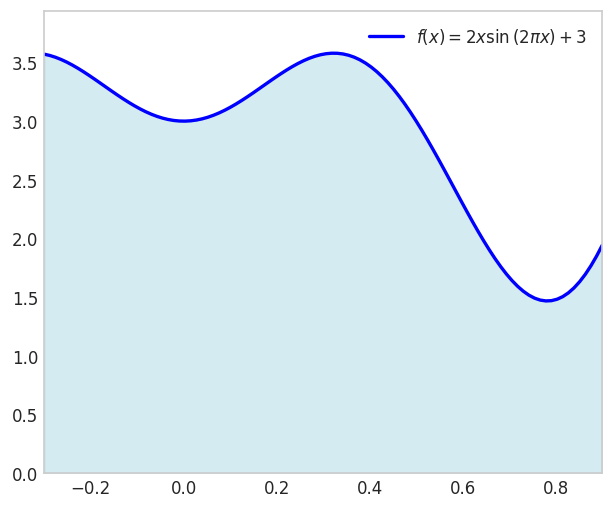

In [52]:
# | code-fold: true
x = sp.Symbol('x')
f_expr = 2*x*sp.sin(2*sp.pi*x) + 3

a = -0.3; b = 0.9

fig, ax = plt.subplots(figsize=(6, 5))

fplot(f_expr, range=(a, b), color='blue', linewidth=2, 
      label=f'$f(x) = {sp.latex(f_expr)}$')

f_numeric = sp.lambdify(x, f_expr, 'numpy')
x_fill = np.linspace(a, b, 500)
y_fill = f_numeric(x_fill)
ax.fill_between(x_fill, y_fill, color='lightblue', alpha=0.5)


ax.set_xlim(a, b)
ax.set_ylim(0, max(y_fill)*1.1)
ax.legend(loc='upper right')
ax.grid(False)
plt.show()

In [53]:
# | code-fold: false

f_num = sp.lambdify(x, f_expr, 'numpy')
I_Quad, error = quad(f_num, 0, 1)

start_time = time.perf_counter()

I_G = gaussint(f_expr, 0, 1, n=8)



end_time = time.perf_counter()
duration = end_time - start_time

error = abs(I_Quad - I_G)


print(f"Result: {I_G}")
print(f"Error vs quad: {error}")
print(f"Evaluation took {duration:.6f} seconds")

Result: 2.681690113379141
Error vs quad: 4.37068603531543e-10
Evaluation took 0.001475 seconds


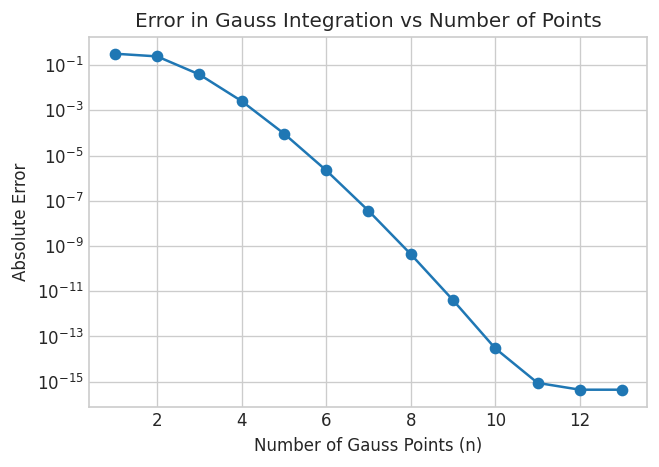

In [54]:
# | code-fold: false

N = range(1,14)
errors = []
for n in N:
    I_G = gaussint(f_expr, 0, 1, n=n)
    error = abs(I_Quad - I_G)
    errors.append(error)

plt.figure(figsize=(6,4))
plt.semilogy(N, errors, marker='o')
plt.xlabel('Number of Gauss Points (n)')
plt.ylabel('Absolute Error')
plt.title('Error in Gauss Integration vs Number of Points')
plt.show()

Here we see that Gauss reaches the same precision as `scipy.integrate.quad` after 12 function evaluations.

## Gauss Visualization

Here is a visualization of the Gauss integration method for the function

$$
f(x)=2 x \sin (12 x)+3 \quad \text{ for }x \in[-0.3,0.9]
$$


In [74]:
# | code-fold: true
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50  # Increase if needed
from matplotlib.colors import to_rgba
from scipy.special import roots_legendre

f_expr = 2*x*sp.sin(12*x) + 3
a = -0.3; b = 0.9
f_numeric = sp.lambdify(x, f_expr, 'numpy')

I_e = quad(f_numeric, a, b)[0]

N_values = list(range(2, 19, 1))
dx = (b - a)/2

def makePlot(N):
    if N < 1: return
    nodes, weights = roots_legendre(N)
    
    x_i = nodes*(b - a)/2 + (b + a)/2
    w_i = weights * (b - a) / 2
    y_i = f_numeric(x_i)
    
    # fig, ax = plt.subplots(figsize=(6, 4))
    # ax.grid(False)
    
    
    edges = np.concatenate(([a], np.cumsum(w_i) + a))
    for i in range(N):
        # Bar spans from edges[i] to edges[i+1]
        # Height is f(x_i)
        w = w_i[i]
        xi = x_i[i]
        yi = y_i[i]
        
        ax.fill_between([edges[i], edges[i+1]], [y_i[i], y_i[i]], 
                    color='cyan', edgecolor='k', alpha=0.5)
        
        ax.plot(xi, yi, 'ko', markersize=4)
    
    fplot(f_expr, range=(a, b), color='red', linewidth=3, ax=ax,
      label=f'$f(x) = {sp.latex(f_expr)}$')    
    ax.set_title(f"N: {N}, Integration error: {abs(I_e - np.sum(w_i * y_i)):.6e}")
    ax.grid(False)
    ax.set_xlim(a, b)
    ax.set_ylim(0, 5)
        


def animate(frame_idx):
    """Animation function for each frame"""
    ax.clear()
    
    N = N_values[frame_idx]
    makePlot(N)

# Create figure and axis (close to prevent static display)
fig, ax = plt.subplots(figsize=(6, 4))
plt.close(fig)  # Prevent static image from showing

# Create animation
anim = FuncAnimation(fig, animate, frames=len(N_values), 
                     interval=800, repeat=True)

# Display as interactive HTML
# HTML(anim.to_jshtml())

# Get the HTML and wrap it with responsive CS
anim_html = anim.to_jshtml()

mk.to_responsive_html(anim, container_id='gauss_animation')

## Alternative Derivation: Polynomial Fitting Perspective

We have seen that Gaussian quadrature nodes are the roots of Legendre polynomials, but this connection may seem somewhat mysterious. An alternative derivation provides geometric intuition by viewing Gaussian quadrature as optimal polynomial approximation.

The key insight is that any function can be locally approximated by a polynomial. If we fit a polynomial $p_n(x)$ of degree $n$ to a function $f(x)$ and integrate the polynomial exactly, we obtain an approximation to the integral of $f$. Since an $n$-point Gaussian rule integrates polynomials of degree up to $2n-1$ exactly, choosing the integration points optimally allows us to integrate the best-fitting polynomial without error. The only approximation error comes from the polynomial fit itself, not from the integration step.

This perspective reveals why Gaussian quadrature is so effective: it separates the approximation error (fitting a polynomial to the function) from the integration error (integrating the polynomial), then eliminates the latter entirely by exact polynomial integration. We formalize this approach by setting up a system of equations that ensures exact integration of all monomials up to degree $2n-1$:

When $f(x)$ is not a polynomial function, we still can approximate the integral by in a sense choosing the closest matching polynomial of the type $p(x)=a_0+a_1 x+a_2 x^2+\ldots+a_n x^n$ and the corresponding Gauss quadrature rule to integrate this polynomial exactly.

![Fitting a polynomial of order $n$ to the function $e^x \sin^2(8x)$](graphics/PolyGaussFit.gif){width=90% align="center"}

![Error plot of the polynomial fitting](graphics/ErrorFit.png){width=90% align="center"}

These special points and weights can be found in several ways. The Golub-Welsch algorithm is the most useful implementation, but we consider another approach that is more intuitive.

::: {.callout-note}
The standard domain for Gauss-Legendre quadrature is $[-1,1]$, reflecting the symmetry of Legendre polynomials about the origin. Most textbooks and reference tables adopt this convention. We use $[0,1]$ as our reference interval throughout this chapter to avoid sign errors when first learning the coordinate transformations. The interval was a natural choice when doing hand-calculations on whiteboards during lectures. The transformation between intervals is straightforward: $\xi \in [-1,1]$ maps to $\eta \in [0,1]$ via $\eta = (\xi+1)/2$. In practice, numerical integration libraries handle these transformations automatically, making the choice of reference interval a matter of pedagogical preference.
:::

For a certain approximation, e.g., the linear

$$
\hat{f}(x)=a_0+a_1 x
$$

we have

$$
w_1 \hat{f}_i\left(x_i\right)=\int_0^1 \hat{f}_i\left(x_i\right) dx
$$

with $\hat{f}_1=1, \hat{f}_2=x$
This yields a system of equations

$$
\begin{cases}w_1 \cdot 1=\int_0^1 1 dx & \Rightarrow w_1=1 \\ w_1 \cdot x_1=\int_0^1 xdx & \Rightarrow x_1=1 / 2\end{cases}
$$

This also works for higher order approximations, e.g., cubic. Note we need polynomial functions which contain even terms since the points and weights are associated with the unknown coefficients $a_i$

$$
\hat{f}(x)=a_0+a_1 x+a_2 x^2+a_3 x^3
$$

with $\hat{f}_1=1, \hat{f}_2=x, \hat{f}_3=x^2, \hat{f}_4=x^3$
from which we form

$$
w_1 \hat{f}_i\left(x_1\right)+w_2 \hat{f}_i\left(x_2\right)=\int_0^1 \hat{f}_i(x) \mathrm{dx}
$$

$$
\left\{\begin{array}{lr}
i=1: & w_1+w_2=\int_0^1 1 dx=1 \\
i=2: & w_1 x_1+w_2 x_2=\int_0^1 \mathrm{xdx}=1 / 2 \\
i=3: & w_1 x_1^2+w_2 x_2^2=\int_0^1 x^2 dx=1 / 3 \\
i=4: & w_1 x_1^3+w_2 x_2^3=\int_0^1 x^3 dx=1 / 4
\end{array}\right.
$$

Now we could solve this symbolically, below, but we shall also see how to solve this system of **non-linear equations** numerically using Newton's method.

In [56]:
import sympy as sp
from mechanicskit import la

w1, w2, x1, x2, x = sp.symbols('w1 w2 x1 x2 x')

# Define equations: (Left Hand Side) - (Right Hand Side) == 0
eqs = [w1*x1**i + w2*x2**i - sp.integrate(x**i, (x, 0, 1)) for i in range(4)]

sol = sp.solve(eqs, [w1, w2, x1, x2])
sol | la

We get two solutions, a mirror of each other.

## Solving the non-linear system of equations

The Newton method states

$$
\mathbf{x}^{k+1}=\mathbf{x}^k-\mathbf{J}\left(\mathbf{x}^k\right)^{-1} \mathbf{f}\left(\mathbf{x}^k\right)
$$

where

$$
\mathbf{J}=\left[\begin{array}{cccc}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_n}{\partial x_1} & \frac{\partial f_n}{\partial x_2} & \cdots & \frac{\partial f_n}{\partial x_n}
\end{array}\right]
$$

Now we rewrite this such that we can turn it into a linear system

$$
\mathbf{J}\left(\mathbf{x}^k\right)\left(\mathbf{x}^{k+1}-\mathbf{x}^k\right)=-\mathbf{f}\left(\mathbf{x}^k\right)
$$

or

$$
\mathbf{A x}=\mathbf{b}
$$

with $\mathbf{A}=\mathbf{J}\left(\mathbf{x}^k\right), \mathbf{x}=\Delta \mathbf{x}=\left(\mathbf{x}^{k+1}-\mathbf{x}^k\right)$ and $\mathbf{b}=-\mathbf{f}\left(\mathbf{x}^k\right)$

We will also need initial values for $w_1, w_2, x_1, x_2$, we will choose randomly such that they all are in the interval $[0,1]$.

In [57]:
import sympy as sp
import numpy as np

# 1. Symbolic Setup
w1, w2, x1, x2, x = sp.symbols('w1 w2 x1 x2 x')
vars = [w1, w2, x1, x2]

# 2. Define Equations (LHS - RHS)
f_exprs = [w1*x1**i + w2*x2**i - sp.integrate(x**i, (x, 0, 1)) for i in range(4)]

# 3. Create Jacobian and Functions (Equivalent to matlabFunction)
J_sym = sp.Matrix(f_exprs).jacobian(vars)
f_num = sp.lambdify(vars, f_exprs, 'numpy')
J_num = sp.lambdify(vars, J_sym, 'numpy')

# 4. Numeric Solver (Newton-Raphson)
x_val = np.random.rand(4)

for i in range(1000):
    f_vec = np.array(f_num(*x_val))
    J_mat = np.array(J_num(*x_val))
    
    # Solve J * delta = -f (Equivalent to J\-f)
    delta = np.linalg.solve(J_mat, -f_vec)
    x_new = x_val + delta
    
    x_str = np.array2string(x_new, formatter={'float_kind': lambda x: f"{x:8.4f}"})
    
    eps = np.linalg.norm(x_new - x_val)
    print(f"Iteration {i}:\t x = {x_str},\t ||delta|| = {eps:.4e}")
    if eps < 1e-12:
        x_val = x_new
        break
    x_val = x_new

print(f"Converged in {i} iterations.")
print(f"Result: {x_val}")

Iteration 0:	 x = [ -2.6397   3.6397   1.6287   0.5537],	 ||delta|| = 4.3982e+00
Iteration 1:	 x = [  0.2457   0.7543   1.6635   0.4917],	 ||delta|| = 4.0812e+00
Iteration 2:	 x = [  0.1796   0.8204   1.3800   0.3160],	 ||delta|| = 3.4633e-01
Iteration 3:	 x = [  0.2238   0.7762   1.0237   0.3280],	 ||delta|| = 3.6199e-01
Iteration 4:	 x = [  0.4143   0.5857   0.7424   0.2594],	 ||delta|| = 3.9547e-01
Iteration 5:	 x = [  0.5012   0.4988   0.8031   0.2139],	 ||delta|| = 1.4441e-01
Iteration 6:	 x = [  0.4991   0.5009   0.7894   0.2116],	 ||delta|| = 1.4204e-02
Iteration 7:	 x = [  0.5000   0.5000   0.7887   0.2113],	 ||delta|| = 1.4411e-03
Iteration 8:	 x = [  0.5000   0.5000   0.7887   0.2113],	 ||delta|| = 2.8941e-06
Iteration 9:	 x = [  0.5000   0.5000   0.7887   0.2113],	 ||delta|| = 7.2428e-12
Iteration 10:	 x = [  0.5000   0.5000   0.7887   0.2113],	 ||delta|| = 9.1593e-16
Converged in 10 iterations.
Result: [0.5        0.5        0.78867513 0.21132487]
